# 09 — Non Compliance and LATE

> 실험 배정을 따르지 않는 사람이 있을 때, 우리는 어떤 효과를 측정하게 될까?

잘 설계된 RCT도 현실에서는 완벽히 실행되지 않습니다. 처치군에 배정됐는데 처치를 거부하거나, 통제군인데 어떻게든 처치를 받는 사람이 생깁니다. 이것이 **불이행(Non-Compliance)** 입니다.

이 챕터는 도구변수(IV)를 새로운 시각으로 바라봅니다. 8장에서는 IV를 "관찰 불가 교란변수를 우회하는 방법"으로 배웠다면, 여기서는 IV를 "인과 사슬의 시작점"으로 봅니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.special import expit
import graphviz
import os

from linearmodels.iv import IV2SLS

os.environ['PATH'] += os.pathsep + r"C:\Program Files\Graphviz\bin"
np.random.seed(42)

mpl.rcParams.update({
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
BLUE, ORANGE, GREEN, RED, PURPLE, GRAY = (
    "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#9370db", "#8c8c8c"
)

---

## 1) 4가지 컴플라이언스 유형

도구변수($Z$, 배정 여부)에 어떻게 반응하느냐에 따라 사람들을 4가지 집단으로 나눌 수 있습니다. 각 집단은 잠재적 처치 $(T_0, T_1)$로 정의됩니다. $T_z$는 "$Z=z$로 배정되었을 때의 실제 처치"를 뜻합니다.

| 집단 | $T_0$ | $T_1$ | 설명 |
|------|--------|--------|------|
| **Compliers** | 0 | 1 | 배정대로 따르는 사람 |
| **Never Takers** | 0 | 0 | 배정에 관계없이 처치를 받지 않는 사람 |
| **Always Takers** | 1 | 1 | 배정에 관계없이 항상 처치를 받는 사람 |
| **Defierers** | 1 | 0 | 배정의 반대로 행동 (현실에서는 거의 없다고 가정) |

한 가지 중요한 점이 있습니다. 데이터에서 각 사람이 어느 집단인지 **알 수 없습니다.** $Z=0$으로 배정된 사람이 $T=0$이면 Complier인지 Never Taker인지 구분할 방법이 없습니다.

아래 DAG는 일반적인 IV 구조입니다. $Z$(배정)이 $T$(실제 처치)에 영향을 주고, 관찰 불가 교란변수 $U$가 $T$와 $Y$ 모두에 영향을 줍니다.

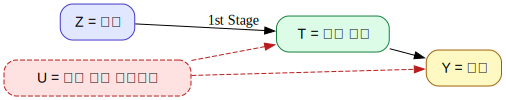

In [2]:
dot = graphviz.Digraph()
dot.attr(rankdir='LR', bgcolor='white')
dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica')
dot.node('Z', 'Z = 배정',       fillcolor='#e0e7ff', color='#4338ca')
dot.node('T', 'T = 실제 처치',  fillcolor='#dcfce7', color='#15803d')
dot.node('Y', 'Y = 결과',       fillcolor='#fef9c3', color='#a16207')
dot.node('U', 'U = 관찰 불가 교란변수', fillcolor='#fee2e2', color='#b91c1c',
         style='rounded,filled,dashed')
dot.edge('Z', 'T', label='1st Stage')
dot.edge('T', 'Y')
dot.edge('U', 'T', style='dashed', color='#b91c1c')
dot.edge('U', 'Y', style='dashed', color='#b91c1c')
dot

---

## 2) Push 마케팅 예시: Non-Compliance의 함정

앱 내 구매를 늘리기 위해 Push 마케팅 실험을 합니다. 5,000명에게 무작위로 Push 배정($Z$)을 합니다. 그런데 소득이 낮은 고객은 구형 스마트폰을 가지고 있어 Push가 전달되지 않습니다(Never Taker). 소득은 인앱 구매에도 직접 영향을 주므로, **소득**이 $T$(실제 수신)와 $Y$(구매) 모두에 영향을 주는 관찰 불가 교란변수가 됩니다.

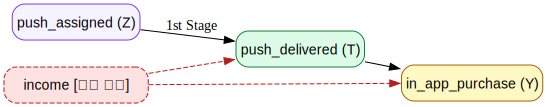

In [3]:
dot2 = graphviz.Digraph()
dot2.attr(rankdir='LR', bgcolor='white')
dot2.attr('node', shape='box', style='rounded,filled', fontname='Helvetica')
dot2.node('Z', 'push_assigned (Z)',   fillcolor='#f5f3ff', color='#7c3aed')
dot2.node('T', 'push_delivered (T)',  fillcolor='#dcfce7', color='#15803d')
dot2.node('Y', 'in_app_purchase (Y)', fillcolor='#fef9c3', color='#a16207')
dot2.node('U', 'income [관찰 불가]', fillcolor='#fee2e2', color='#b91c1c',
         style='rounded,filled,dashed')
dot2.edge('Z', 'T', label='1st Stage')
dot2.edge('T', 'Y')
dot2.edge('U', 'T', style='dashed', color='#b91c1c', label='구형폰')
dot2.edge('U', 'Y', style='dashed', color='#b91c1c')
dot2

아래에서 데이터를 생성합니다. 진짜 LATE(Push 수신의 효과)는 **3.0**으로 설정합니다.

In [4]:
n = 5000
income = np.random.normal(50, 15, n).clip(10, 100)
push_assigned = np.random.binomial(1, 0.5, n)
has_new_phone = np.random.binomial(1, expit((income - 50) / 15), n)
push_delivered = push_assigned * has_new_phone
in_app_purchase = 50 + 0.4 * income + 3.0 * push_delivered + np.random.normal(0, 5, n)

data = pd.DataFrame({
    'push_assigned': push_assigned,
    'push_delivered': push_delivered,
    'in_app_purchase': in_app_purchase,
    'income': income,
})

pd.crosstab(data.push_assigned, data.push_delivered,
            rownames=['push_assigned (Z)'], colnames=['push_delivered (T)'],
            normalize='index').round(3)

push_delivered (T),0,1
push_assigned (Z),,
0,1.000,0.000
1,0.505,0.495


교차표에서, $Z=0$인 사람은 100% $T=0$이고, $Z=1$인 사람은 약 절반(49.5%)만 실제로 Push를 받았습니다. 나머지 50.5%는 배정받았지만 구형폰이라 못 받은 Never Taker입니다.

---

## 3) OLS가 왜 틀리는가?

`push_delivered`를 처치변수로 OLS를 돌리면 `push_delivered=1`인 그룹은 신형폰 → 소득 높음 → 원래 구매를 많이 하는 사람들입니다. 반면 `push_delivered=0`에는 소득이 낮은 Never Taker가 섞여 있습니다. 이 두 그룹을 비교하면 Push의 효과가 아니라 **소득 차이**를 측정하게 됩니다.

In [5]:
m_ols = smf.ols("in_app_purchase ~ push_assigned + push_delivered", data=data).fit()
m_ols.params.round(3).to_frame("계수")

,계수
Intercept,70.153
push_assigned,-2.630
push_delivered,8.411


`push_delivered` 계수가 8.4로 참값 3.0의 거의 세 배입니다. 게다가 `push_assigned` 계수가 음수(-2.6)인데, "배정받으면 오히려 구매가 줄어든다"는 말이 되어 직관에 완전히 반합니다. 소득이라는 관찰 불가 교란변수가 OLS를 망가뜨린 결과입니다.

---

## 4) ITT(Intent-to-Treat): 편향 없지만 희석된 추정치

실제 처치(`push_delivered`) 대신 **배정 여부**(`push_assigned`)를 처치변수로 사용하는 것이 ITT입니다. 배정은 무작위이므로 소득과 무관합니다.

$$ITT = E[Y \mid Z=1] - E[Y \mid Z=0]$$

단, ITT는 "Push 배정"의 효과이지 "Push 전달"의 효과가 아닙니다. Never Taker들은 Push를 받지 못해 효과가 0이므로 ITT가 희석됩니다.

$$ITT = LATE \times P(\text{Complier})$$

In [6]:
m_itt = smf.ols("in_app_purchase ~ push_assigned", data=data).fit()
itt   = m_itt.params['push_assigned']
m_itt.params.round(3).to_frame("계수")

,계수
Intercept,70.153
push_assigned,1.531


ITT = 1.53으로 편향은 없지만 참값 3.0보다 작습니다. Complier 비율(약 49%)만큼 희석된 것입니다.

---

## 5) LATE: Complier에 대한 처치 효과

### 5-1. 1단계와 Wald Estimator

ITT를 Complier 비율(1단계)로 나누면 희석이 되돌아옵니다.

$$LATE = \frac{ITT}{\text{1st Stage}} = \frac{E[Y \mid Z=1] - E[Y \mid Z=0]}{E[T \mid Z=1] - E[T \mid Z=0]}$$

분모인 1단계는 $P(\text{Complier})$와 같습니다. 결국 LATE는 **Complier에 대한 ATE**입니다.

In [7]:
m_first = smf.ols("push_delivered ~ push_assigned", data=data).fit()
first_stage = m_first.params['push_assigned']
late_wald = itt / first_stage

pd.DataFrame({
    "추정량": ["1st Stage (Complier 비율)", "ITT", "LATE (Wald)", "참값"],
    "값": [first_stage, itt, late_wald, 3.0]
}).round(4)

,추정량,값
0,1st Stage (Complier 비율),0.4947
1,ITT,1.5311
2,LATE (Wald),3.0950
3,참값,3.0000


1단계 계수(0.495)가 Complier 비율입니다. ITT(1.53)를 이로 나누면 LATE = 3.09로, 참값 3.0에 매우 가깝습니다.

### 5-2. 2SLS로 LATE 구하기

`push_assigned`를 `push_delivered`의 도구변수로 사용하는 2SLS입니다. Wald와 동일한 계수를 내면서, 올바른 표준오차(SE)까지 계산해줍니다. 수동으로 ITT / 1st Stage를 계산하면 계수는 맞는데 SE가 틀리므로 라이브러리를 사용하는 것이 좋습니다.

In [8]:
result_iv = IV2SLS.from_formula(
    "in_app_purchase ~ 1 + [push_delivered ~ push_assigned]",
    data=data
).fit(cov_type="unadjusted")

pd.DataFrame({
    "모델": ["OLS (편향)", "ITT (희석)", "2SLS / LATE", "참값"],
    "push 계수": [m_ols.params['push_delivered'], itt, result_iv.params['push_delivered'], 3.0],
}).round(3)

,모델,push 계수
0,OLS (편향),8.411
1,ITT (희석),1.531
2,2SLS / LATE,3.095
3,참값,3.000


OLS(8.4) → ITT(1.5) → 2SLS(3.1) 순서로 참값 3.0에 가까워집니다.

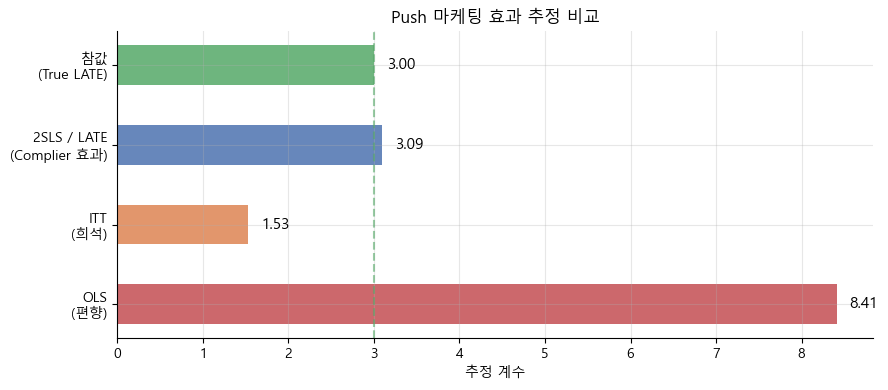

In [9]:
labels = ["OLS\n(편향)", "ITT\n(희석)", "2SLS / LATE\n(Complier 효과)", "참값\n(True LATE)"]
values = [m_ols.params['push_delivered'], itt, result_iv.params['push_delivered'], 3.0]
colors = [RED, ORANGE, BLUE, GREEN]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors, alpha=0.85, height=0.5)
for bar, val in zip(bars, values):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=11)
ax.axvline(3.0, color=GREEN, ls="--", lw=1.5, alpha=0.6)
ax.set_xlabel("추정 계수")
ax.set_title("Push 마케팅 효과 추정 비교")
plt.tight_layout()
plt.show()

---

## 6) 단조성 가정과 LATE의 전제 조건

LATE 추정이 유효하려면 4가지 조건이 필요합니다.

1. **독립성:** $Z$가 무작위로 배정됩니다.
2. **배제 제한:** $Z$는 $T$를 통해서만 $Y$에 영향을 줍니다.
3. **1단계:** $Z$가 $T$에 실제로 영향을 줍니다.
4. **단조성:** $T_{i1} \geq T_{i0}$ — Defier가 없습니다.

단조성은 "Push 배정을 받으면, 배정받지 않은 경우보다 Push를 받을 확률이 높다"는 자연스러운 가정입니다. 데이터에서는 $(Z=0, T=1)$ 셀, 즉 배정받지 않았는데 처치를 받은 비율(Always Taker)이 0에 가까우면 단조성이 성립한다고 볼 수 있습니다.

In [10]:
ct = pd.crosstab(data.push_assigned, data.push_delivered,
                 rownames=['push_assigned (Z)'], colnames=['push_delivered (T)'],
                 normalize='index').round(3)

always_taker = ct.loc[0, 1]
never_taker = ct.loc[1, 0]
complier = 1 - always_taker - never_taker

pd.DataFrame({
    "집단": ["Always Taker", "Never Taker", "Complier"],
    "비율": [always_taker, never_taker, complier],
    "위치": ["(Z=0, T=1)", "(Z=1, T=0)", "1 - 나머지"]
}).round(3)

,집단,비율,위치
0,Always Taker,0.000,"(Z=0, T=1)"
1,Never Taker,0.505,"(Z=1, T=0)"
2,Complier,0.495,1 - 나머지


Always Taker 비율이 0으로 단조성이 성립합니다. Never Taker가 약 50%이므로, Complier는 나머지 약 50%입니다.

---

## 7) ITT vs LATE: 어떤 질문에 답하는가?

두 추정치는 서로 다른 질문에 답합니다.

- **ITT**: "이번 캠페인을 전체 고객에게 배정하면 총 매출이 얼마나 늘어나는가?" Never Taker가 포함된 현실적인 운영 환경을 반영하므로 비즈니스 의사결정에 적합합니다.
- **LATE**: "Push를 기술적으로 개선해서 모든 고객에게 전달된다면 효과가 얼마나 될까?" 처치 기술 자체의 효과를 봅니다. 단, 항상 "이 효과는 Complier에 국한된 것"임을 명시해야 합니다.

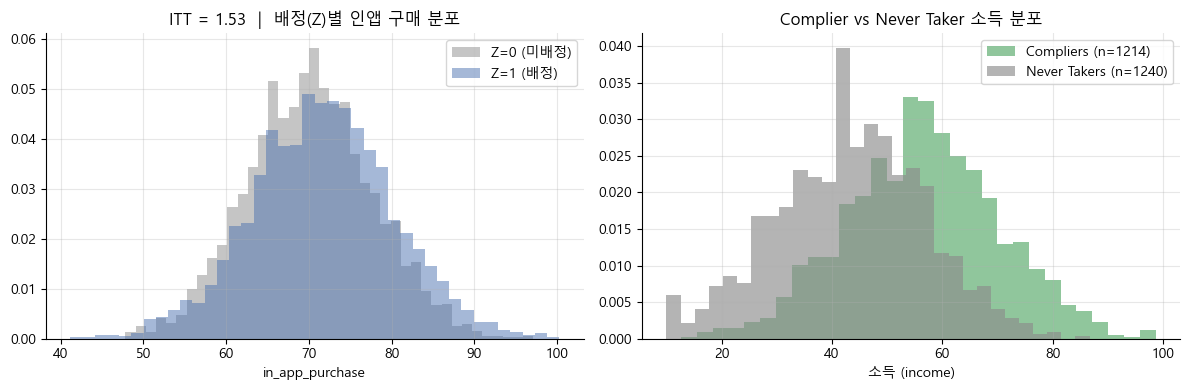

In [11]:
compliers_inc = data[(data.push_assigned==1) & (data.push_delivered==1)]['income']
never_inc = data[(data.push_assigned==1) & (data.push_delivered==0)]['income']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for z_val, label, color in [(0, 'Z=0 (미배정)', GRAY), (1, 'Z=1 (배정)', BLUE)]:
    axes[0].hist(data[data.push_assigned == z_val]['in_app_purchase'],
                 bins=40, alpha=0.5, label=label, color=color, density=True)
axes[0].set_xlabel('in_app_purchase')
axes[0].set_title(f'ITT = {itt:.2f}  |  배정(Z)별 인앱 구매 분포')
axes[0].legend()

axes[1].hist(compliers_inc, bins=30, alpha=0.65, label=f'Compliers (n={len(compliers_inc)})',
             color=GREEN, density=True)
axes[1].hist(never_inc, bins=30, alpha=0.65, label=f'Never Takers (n={len(never_inc)})',
             color=GRAY, density=True)
axes[1].set_xlabel('소득 (income)')
axes[1].set_title('Complier vs Never Taker 소득 분포')
axes[1].legend()

plt.tight_layout()
plt.show()

오른쪽 그래프에서 Complier(초록)는 소득이 높고, Never Taker(회색)는 소득이 낮습니다. OLS가 단순 비교를 했을 때 이 소득 차이를 Push 효과로 잘못 귀속시켰던 것입니다.

---

## 핵심 정리

| 개념 | 정의 | 비고 |
|------|------|------|
| **Non-Compliance** | 배정($Z$)과 실제 처치($T$)가 불일치 | |
| **Compliers** | $T_0=0, T_1=1$ | IV 추정의 타겟 |
| **Never Takers** | $T_0=0, T_1=0$ | 1단계를 희석 |
| **Always Takers** | $T_0=1, T_1=1$ | 절편 ≠ 0이면 존재 |
| **ITT** | $E[Y\mid Z=1] - E[Y\mid Z=0]$ | 편향 없음, 처치 효과보다 작음 |
| **1st Stage** | $E[T\mid Z=1] - E[T\mid Z=0]$ | Complier 비율 |
| **LATE** | $ITT \;/\; \text{1st Stage}$ | Complier에 대한 처치 효과 |
| **단조성** | $T_{i1} \geq T_{i0}$ | Defier 없음 |

> IV를 바라보는 새로운 시각: 8장에서 IV를 "관찰 불가 교란변수를 우회하는 방법"으로 배웠다면, 9장에서는 IV를 "인과 사슬의 시작점"으로 봅니다. IV 추정치는 항상 **$Z$에 의해 $T$가 변한 사람들(Complier)** 에 대한 효과입니다.

---
*참고: Matheus Facure, Python Causality Handbook, Chapter 09*  
*Angrist, Imbens & Rubin (1996). Identification of Causal Effects Using Instrumental Variables. JASA.*